In [1]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 26.4 MB/s eta 0:00:00


In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import Descriptors

In [3]:
######################################
# Phase 1 - Retrieve ChEMBL Dataset
######################################

In [4]:
url = "https://www.ebi.ac.uk/chembl/api/data/molecule.json?limit=2000"

response = requests.get(url)

data = response.json()

print("Data downloaded successfully")

Data downloaded successfully


In [5]:
print(data.keys())

dict_keys(['molecules', 'page_meta'])


In [6]:
molecules = []

for mol in data["molecules"]:

    if mol.get("molecule_structures"):

        smiles = mol["molecule_structures"].get(
            "canonical_smiles"
        )

        chembl_id = mol.get(
            "molecule_chembl_id"
        )

        molecules.append(
            [chembl_id, smiles]
        )

print("Number of molecules:", len(molecules))

Number of molecules: 969


In [7]:
df = pd.DataFrame(
    molecules,
    columns=["ChEMBL_ID", "SMILES"]
)

df.head()

,ChEMBL_ID,SMILES
0,CHEMBL6329,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccccc1Cl
1,CHEMBL6328,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccc(C#N)cc1
2,CHEMBL265667,Cc1cc(-n2ncc(=O)[nH]c2=O)cc(C)c1C(O)c1ccc(Cl)cc1
3,CHEMBL6362,Cc1ccc(C(=O)c2ccc(-n3ncc(=O)[nH]c3=O)cc2)cc1
4,CHEMBL267864,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccc(Cl)cc1


In [8]:
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

Shape: (969, 2)

Missing values:
ChEMBL_ID    0
SMILES       0
dtype: int64


In [9]:
mw_list = []
logp_list = []
hbd_list = []
hba_list = []
tpsa_list = []
rotbond_list = []
ring_list = []
atomcount_list = []

In [10]:
######################################
# Phase 2 - Descriptor Calculation
######################################

In [11]:
for smiles in df["SMILES"]:

    mol = Chem.MolFromSmiles(smiles)

    if mol:

        mw_list.append(
            Descriptors.MolWt(mol)
        )

        logp_list.append(
            Descriptors.MolLogP(mol)
        )

        hbd_list.append(
            Descriptors.NumHDonors(mol)
        )

        hba_list.append(
            Descriptors.NumHAcceptors(mol)
        )

        tpsa_list.append(
            Descriptors.TPSA(mol)
        )

        rotbond_list.append(
            Descriptors.NumRotatableBonds(mol)
        )

        ring_list.append(
            Descriptors.RingCount(mol)
        )

        atomcount_list.append(
            mol.GetNumAtoms()
        )

    else:

        mw_list.append(None)
        logp_list.append(None)
        hbd_list.append(None)
        hba_list.append(None)
        tpsa_list.append(None)
        rotbond_list.append(None)
        ring_list.append(None)
        atomcount_list.append(None)

print("Descriptor calculation complete")

Descriptor calculation complete


In [12]:
df["MW"] = mw_list
df["LogP"] = logp_list
df["HBD"] = hbd_list
df["HBA"] = hba_list
df["TPSA"] = tpsa_list
df["RotBonds"] = rotbond_list
df["Rings"] = ring_list
df["AtomCount"] = atomcount_list

df.head()

,ChEMBL_ID,SMILES,MW,LogP,HBD,HBA,TPSA,RotBonds,Rings,AtomCount
0,CHEMBL6329,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccccc1Cl,341.754,2.11362,1,4,84.82,3,3,24
1,CHEMBL6328,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccc(C#N)cc1,332.319,1.33190,1,5,108.61,3,3,25
2,CHEMBL265667,Cc1cc(-n2ncc(=O)[nH]c2=O)cc(C)c1C(O)c1ccc(Cl)cc1,357.797,2.27274,2,4,87.98,3,3,25
3,CHEMBL6362,Cc1ccc(C(=O)c2ccc(-n3ncc(=O)[nH]c3=O)cc2)cc1,307.309,1.46022,1,4,84.82,3,3,23
4,CHEMBL267864,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccc(Cl)cc1,341.754,2.11362,1,4,84.82,3,3,24


In [13]:
df = df.dropna()

print("Clean dataset shape:")
print(df.shape)

Clean dataset shape:
(969, 10)


In [14]:
df.describe()

,MW,LogP,HBD,HBA,TPSA,RotBonds,Rings,AtomCount
count,969.000000,969.000000,969.000000,969.000000,969.000000,969.000000,969.000000,969.000000
mean,394.868967,2.550836,1.972136,5.246646,93.107781,5.671827,3.055728,27.333333
std,210.756050,2.292004,2.946185,3.385380,89.819636,6.949912,1.220939,14.835438
min,98.149000,-8.992900,0.000000,1.000000,3.240000,0.000000,0.000000,7.000000
25%,274.412000,1.491700,1.000000,3.000000,46.840000,2.000000,2.000000,19.000000
50%,347.802000,2.658420,1.000000,4.000000,75.190000,4.000000,3.000000,24.000000
75%,437.475000,3.806470,2.000000,6.000000,103.600000,6.000000,4.000000,31.000000
max,1958.135000,10.255700,29.000000,29.000000,810.330000,58.000000,11.000000,137.000000


In [15]:
df.to_csv(
    "compound_descriptors.csv",
    index=False
)

print("Dataset saved successfully")

Dataset saved successfully


In [16]:
######################################
# Phase 3 - Drug-Likeness Filters
######################################

In [17]:
def lipinski_pass(row):

    if (
        row["MW"] <= 500 and
        row["LogP"] <= 5 and
        row["HBD"] <= 5 and
        row["HBA"] <= 10
    ):
        return "Pass"

    return "Fail"

In [18]:
df["Lipinski"] = df.apply(
    lipinski_pass,
    axis=1
)



In [19]:
def veber_pass(row):

    if (
        row["TPSA"] <= 140 and
        row["RotBonds"] <= 10
    ):
        return "Pass"

    return "Fail"

In [20]:
df["Veber"] = df.apply(
    veber_pass,
    axis=1
)



In [21]:
def ghose_pass(row):

    if (
        160 <= row["MW"] <= 480 and
        -0.4 <= row["LogP"] <= 5.6 and
        20 <= row["AtomCount"] <= 70
    ):
        return "Pass"

    return "Fail"

In [22]:
df["Ghose"] = df.apply(
    ghose_pass,
    axis=1
)



In [23]:
def egan_pass(row):

    if (
        row["TPSA"] <= 131 and
        row["LogP"] <= 5.88
    ):
        return "Pass"

    return "Fail"

In [24]:
df["Egan"] = df.apply(
    egan_pass,
    axis=1
)



In [25]:
df.head()

,ChEMBL_ID,SMILES,MW,LogP,HBD,HBA,TPSA,RotBonds,Rings,AtomCount,Lipinski,Veber,Ghose,Egan
0,CHEMBL6329,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccccc1Cl,341.754,2.11362,1,4,84.82,3,3,24,Pass,Pass,Pass,Pass
1,CHEMBL6328,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccc(C#N)cc1,332.319,1.33190,1,5,108.61,3,3,25,Pass,Pass,Pass,Pass
2,CHEMBL265667,Cc1cc(-n2ncc(=O)[nH]c2=O)cc(C)c1C(O)c1ccc(Cl)cc1,357.797,2.27274,2,4,87.98,3,3,25,Pass,Pass,Pass,Pass
3,CHEMBL6362,Cc1ccc(C(=O)c2ccc(-n3ncc(=O)[nH]c3=O)cc2)cc1,307.309,1.46022,1,4,84.82,3,3,23,Pass,Pass,Pass,Pass
4,CHEMBL267864,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccc(Cl)cc1,341.754,2.11362,1,4,84.82,3,3,24,Pass,Pass,Pass,Pass


In [26]:
summary = pd.DataFrame({

    "Filter": [
        "Lipinski",
        "Veber",
        "Ghose",
        "Egan"
    ],

    "Pass": [
        (df["Lipinski"]=="Pass").sum(),
        (df["Veber"]=="Pass").sum(),
        (df["Ghose"]=="Pass").sum(),
        (df["Egan"]=="Pass").sum()
    ],

    "Fail": [
        (df["Lipinski"]=="Fail").sum(),
        (df["Veber"]=="Fail").sum(),
        (df["Ghose"]=="Fail").sum(),
        (df["Egan"]=="Fail").sum()
    ]
})

summary

,Filter,Pass,Fail
0,Lipinski,769,200
1,Veber,818,151
2,Ghose,489,480
3,Egan,796,173


In [27]:
df.to_csv(
    "compound_filter_results.csv",
    index=False
)

print("Phase 2 dataset saved")

Phase 2 dataset saved


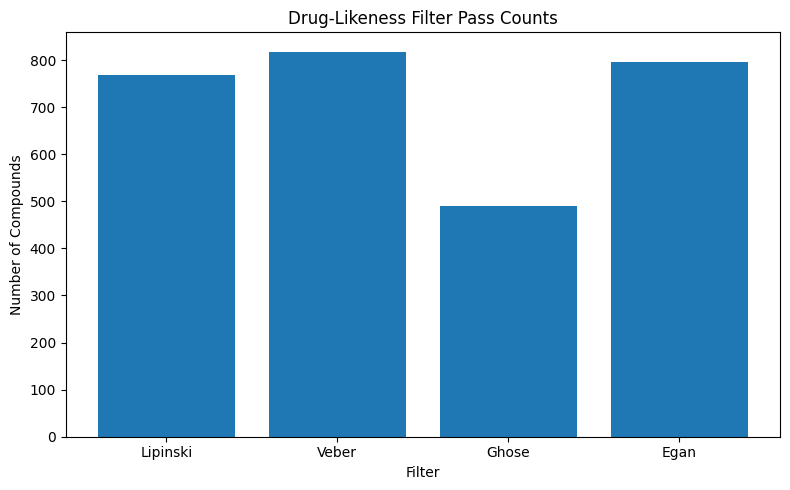

In [28]:
plt.figure(figsize=(8,5))

plt.bar(
    summary["Filter"],
    summary["Pass"]
)

plt.title("Drug-Likeness Filter Pass Counts")

plt.xlabel("Filter")

plt.ylabel("Number of Compounds")

plt.tight_layout()

plt.savefig(
    "filter_pass_comparison.png",
    dpi=300
)

plt.show()

In [29]:
total_compounds = len(df)

summary["Pass_Percentage"] = (
    summary["Pass"] /
    total_compounds
) * 100

summary

,Filter,Pass,Fail,Pass_Percentage
0,Lipinski,769,200,79.360165
1,Veber,818,151,84.416925
2,Ghose,489,480,50.464396
3,Egan,796,173,82.146543


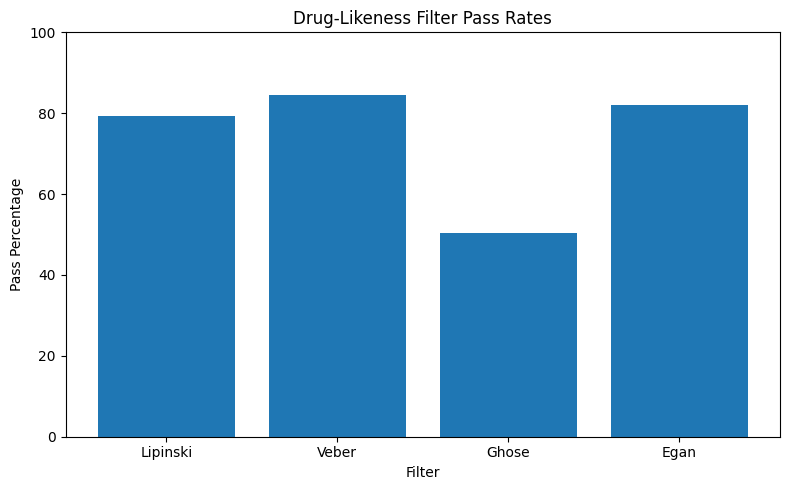

In [30]:
plt.figure(figsize=(8,5))

plt.bar(
    summary["Filter"],
    summary["Pass_Percentage"]
)

plt.ylabel("Pass Percentage")

plt.xlabel("Filter")

plt.title(
    "Drug-Likeness Filter Pass Rates"
)

plt.ylim(0,100)

plt.tight_layout()

plt.savefig(
    "filter_pass_percentages.png",
    dpi=300
)

plt.show()

In [31]:
corr = df[
    [
        "MW",
        "LogP",
        "HBD",
        "HBA",
        "TPSA",
        "RotBonds",
        "Rings",
        "AtomCount"
    ]
].corr()

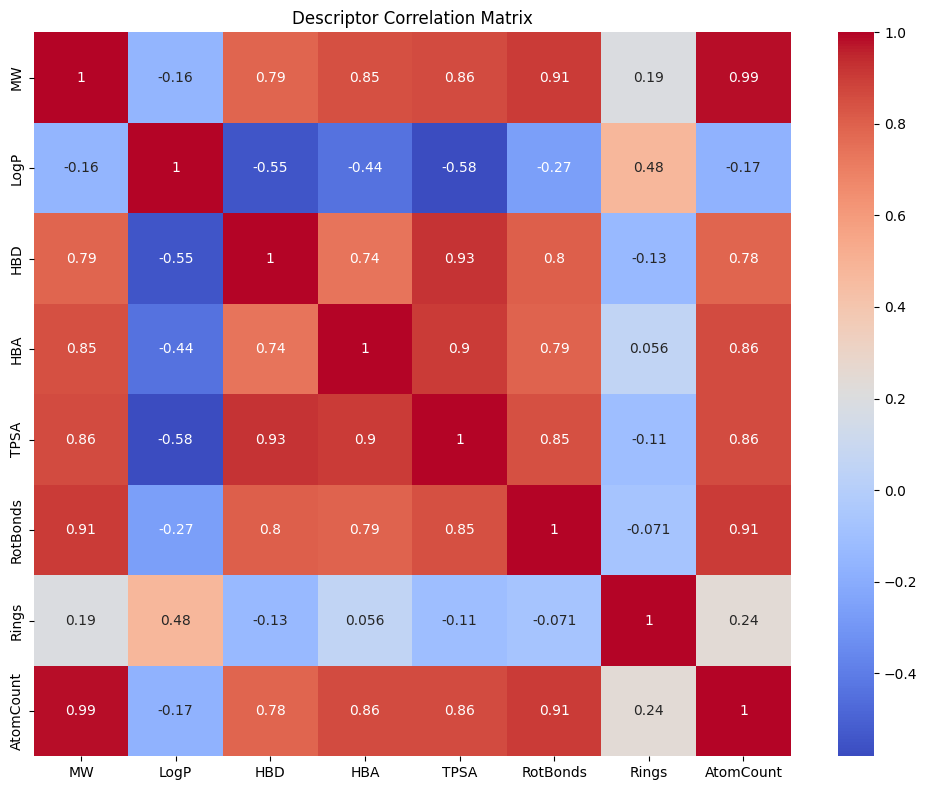

In [32]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Descriptor Correlation Matrix"
)

plt.tight_layout()

plt.savefig(
    "descriptor_heatmap.png",
    dpi=300
)

plt.show()

In [33]:
summary.to_csv(
    "filter_summary.csv",
    index=False
)

print("Summary saved")

Summary saved


In [34]:
from rdkit.Chem.FilterCatalog import (
    FilterCatalog,
    FilterCatalogParams
)

In [35]:
params = FilterCatalogParams()

params.AddCatalog(
    FilterCatalogParams.FilterCatalogs.PAINS
)

pains_catalog = FilterCatalog(params)

print("PAINS catalog loaded")

PAINS catalog loaded


In [36]:
test_smiles = df.iloc[0]["SMILES"]

mol = Chem.MolFromSmiles(test_smiles)

match = pains_catalog.GetFirstMatch(mol)

print(match)

None


In [37]:
def check_pains(smiles):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return "Invalid"

    match = pains_catalog.GetFirstMatch(mol)

    if match:
        return "PAINS"

    return "Clean"

In [38]:
df["PAINS"] = df["SMILES"].apply(
    check_pains
)

df["PAINS"].value_counts()

,count
PAINS,
Clean,924
PAINS,45


In [39]:
pains_summary = df["PAINS"].value_counts()

print(pains_summary)

print("\nPercentages:\n")

print(
    round(
        df["PAINS"].value_counts(normalize=True) * 100,
        2
    )
)

PAINS
Clean    924
PAINS     45
Name: count, dtype: int64

Percentages:

PAINS
Clean    95.36
PAINS     4.64
Name: proportion, dtype: float64


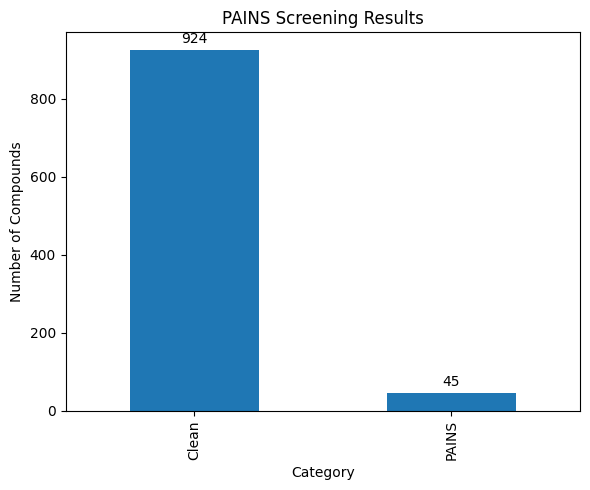

In [40]:

ax = df["PAINS"].value_counts().plot(
    kind="bar",
    figsize=(6,5)
)

plt.title("PAINS Screening Results")
plt.xlabel("Category")
plt.ylabel("Number of Compounds")

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()

plt.savefig(
    "pains_screening.png",
    dpi=300
)

plt.show()

In [41]:
pains_hits = df[
    df["PAINS"] == "PAINS"
]

print(
    pains_hits[
        ["ChEMBL_ID","SMILES"]
    ].head(10)
)

        ChEMBL_ID                                             SMILES
80     CHEMBL6313  COc1cc2nc(N3CCN(/C(S)=N/c4ccc(N=[N+]=[N-])cc4)...
84   CHEMBL204146                    O=c1oc2c(O)c(O)ccc2c2ccc(O)cc12
86     CHEMBL6364                       O=c1oc2c(O)c(O)ccc2c2ccccc12
87     CHEMBL6365                       O=c1oc2ccccc2c2cc(O)c(O)cc12
88   CHEMBL266458                 O=c1oc2cc(O)c(O)cc2c2cc(O)c(O)cc12
99   CHEMBL263076                    O=c1oc2c(O)c(O)ccc2c2cc(F)ccc12
100    CHEMBL6335               O=c1oc2c(Cl)c(Cl)ccc2c2cc(O)c(O)cc12
101    CHEMBL6336                 Cc1cc(O)c(O)c2oc(=O)c3ccc(F)cc3c12
102    CHEMBL6353                 ONC1c2cc(O)c(O)cc2-c2cc(O)c(O)cc21
103    CHEMBL6345                 O=C1c2cc(O)c(O)cc2-c2cc(O)c(O)cc21


In [42]:
df.to_csv(
    "compound_filter_results_with_pains.csv",
    index=False
)

print("PAINS screening complete")

PAINS screening complete


In [43]:
df["PAINS"].value_counts()

,count
PAINS,
Clean,924
PAINS,45


In [44]:
params_brenk = FilterCatalogParams()

params_brenk.AddCatalog(
    FilterCatalogParams.FilterCatalogs.BRENK
)

brenk_catalog = FilterCatalog(
    params_brenk
)

print("Brenk catalog loaded")

Brenk catalog loaded


In [45]:
test_smiles = df.iloc[0]["SMILES"]

mol = Chem.MolFromSmiles(test_smiles)

match = brenk_catalog.GetFirstMatch(mol)

print(match)

None


In [46]:
def check_brenk(smiles):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return "Invalid"

    match = brenk_catalog.GetFirstMatch(mol)

    if match:
        return "Alert"

    return "Clean"

In [47]:
df["Brenk"] = df["SMILES"].apply(
    check_brenk
)

df["Brenk"].value_counts()

,count
Brenk,
Clean,523
Alert,446


In [48]:
df["Lipinski_Score"] = (
    df["Lipinski"] == "Pass"
).astype(int)

df["Veber_Score"] = (
    df["Veber"] == "Pass"
).astype(int)

df["Ghose_Score"] = (
    df["Ghose"] == "Pass"
).astype(int)

df["Egan_Score"] = (
    df["Egan"] == "Pass"
).astype(int)

df["PAINS_Score"] = (
    df["PAINS"] == "Clean"
).astype(int)

df["Brenk_Score"] = (
    df["Brenk"] == "Clean"
).astype(int)

In [49]:
df["Quality_Score"] = (

    df["Lipinski_Score"] +
    df["Veber_Score"] +
    df["Ghose_Score"] +
    df["Egan_Score"] +
    df["PAINS_Score"] +
    df["Brenk_Score"]

)

df["Quality_Score"].describe()

,Quality_Score
count,969.000000
mean,4.457172
std,1.572777
min,0.000000
25%,4.000000
50%,5.000000
75%,6.000000
max,6.000000


In [50]:
def classify_quality(score):

    if score >= 6:
        return "Excellent"

    elif score >= 5:
        return "Good"

    elif score >= 3:
        return "Moderate"

    return "Poor"

In [51]:
df["Quality_Class"] = (
    df["Quality_Score"]
    .apply(classify_quality)
)

df["Quality_Class"].value_counts()

,count
Quality_Class,
Good,362
Excellent,269
Moderate,186
Poor,152


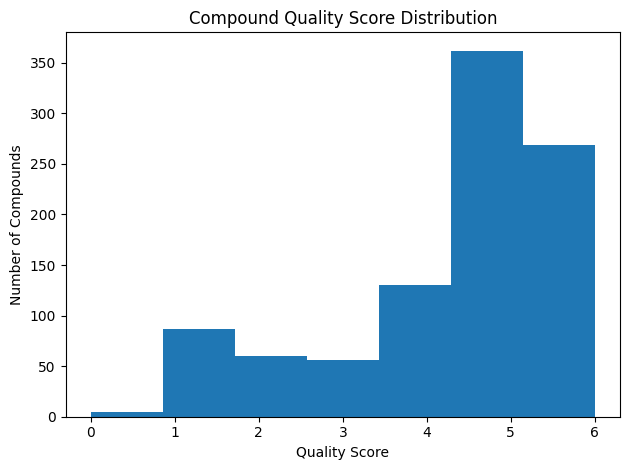

In [52]:
df["Quality_Score"].plot(
    kind="hist",
    bins=7
)

plt.title(
    "Compound Quality Score Distribution"
)

plt.xlabel(
    "Quality Score"
)

plt.ylabel(
    "Number of Compounds"
)

plt.tight_layout()

plt.savefig(
    "quality_score_distribution.png",
    dpi=300
)

plt.show()

In [53]:
top_compounds = df.sort_values(
    by="Quality_Score",
    ascending=False
)

top_compounds[
    [
        "ChEMBL_ID",
        "Quality_Score",
        "Quality_Class"
    ]
].head(20)

,ChEMBL_ID,Quality_Score,Quality_Class
966,CHEMBL6933,6,Excellent
0,CHEMBL6329,6,Excellent
1,CHEMBL6328,6,Excellent
2,CHEMBL265667,6,Excellent
3,CHEMBL6362,6,Excellent
4,CHEMBL267864,6,Excellent
5,CHEMBL6363,6,Excellent
944,CHEMBL6826,6,Excellent
943,CHEMBL6655,6,Excellent
37,CHEMBL263077,6,Excellent


In [54]:
df.to_csv(
    "final_compound_screening_pipeline.csv",
    index=False
)

print("Final screening dataset saved")

Final screening dataset saved


In [55]:
df["Quality_Class"].value_counts()

,count
Quality_Class,
Good,362
Excellent,269
Moderate,186
Poor,152


In [56]:
top50 = df.sort_values(
    by="Quality_Score",
    ascending=False
).head(50)

top50.to_csv(
    "top_50_compounds.csv",
    index=False
)

In [57]:
print("=" * 50)
print("Drug-Likeness Screening Pipeline Completed Successfully")
print("=" * 50)
print(f"Total compounds analyzed: {len(df)}")
print("Results exported successfully.")

Drug-Likeness Screening Pipeline Completed Successfully
Total compounds analyzed: 969
Results exported successfully.
